In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif


In [26]:
# 1. LOAD DATASET
# ============================================================

file_path = "d:/Downloads/Final_Attrition_Dataset_200_Employees.csv"

df = pd.read_csv(file_path)

target = "Will_Resign_in_Next_6_Months"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [27]:
# 2. BASIC DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
print(df.head())

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
print(df.columns.tolist())

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
df.info()


DATASET SHAPE
Rows: 200
Columns: 24

FIRST 5 ROWS
  Employee_ID Employee_Name   Department     Job_Level Work_Mode  Shift_Type  \
0      EMP001  Sonia Hassan           HR  Lead/Manager    Hybrid         Day   
1      EMP002    Bilal Aziz        Sales           Mid    Onsite  Rotational   
2      EMP003    Kamran Ali      Finance           Mid    Remote         Day   
3      EMP004    Ali Masood      Finance           Mid    Onsite         Day   
4      EMP005   Farhan Shah  Engineering        Junior    Remote         Day   

   Tenure_Months  Monthly_Salary_PKR  Salary_vs_Market_pct  \
0            140              233000                   5.3   
1             37              132000                  19.5   
2             14              100000                  -8.9   
3             39               96000                 -13.0   
4             16               72000                   4.8   

   Last_Increment_pct  ...  Absence_Days_Last_90D  Engagement_Score  \
0                 5.7  ..

In [28]:
# 3. MISSING VALUES
# ============================================================

missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values.sort_values(
    by="Missing_Percentage",
    ascending=False
)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(missing_values)

missing_only = missing_values[
    missing_values["Missing_Count"] > 0
]

if len(missing_only) == 0:
    print("\nNo missing values found.")
else:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=missing_only.reset_index(),
        x="Missing_Percentage",
        y="index"
    )

    plt.title("Missing Values Percentage")
    plt.xlabel("Missing Percentage")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



MISSING VALUES
                              Missing_Count  Missing_Percentage
Employee_ID                               0                 0.0
Employee_Name                             0                 0.0
Department                                0                 0.0
Job_Level                                 0                 0.0
Work_Mode                                 0                 0.0
Shift_Type                                0                 0.0
Tenure_Months                             0                 0.0
Monthly_Salary_PKR                        0                 0.0
Salary_vs_Market_pct                      0                 0.0
Last_Increment_pct                        0                 0.0
Months_Since_Last_Promotion               0                 0.0
KPI_Achievement_pct                       0                 0.0
Performance_Trend_6M                      0                 0.0
Overtime_Hours_Last_30D                   0                 0.0
Absence_Days_Last_90D   

In [30]:
# 4. DUPLICATE RECORDS
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

print("Complete duplicate rows:", df.duplicated().sum())
print(
    "Duplicate Employee IDs:",
    df["Employee_ID"].duplicated().sum()
)



DUPLICATE RECORDS
Complete duplicate rows: 0
Duplicate Employee IDs: 0


In [31]:
# ============================================================
# 5. UNIQUE VALUES
# ============================================================

print("\n" + "=" * 70)
print("UNIQUE VALUES IN EACH COLUMN")
print("=" * 70)

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")




UNIQUE VALUES IN EACH COLUMN
Employee_ID: 200 unique values
Employee_Name: 200 unique values
Department: 7 unique values
Job_Level: 4 unique values
Work_Mode: 3 unique values
Shift_Type: 3 unique values
Tenure_Months: 94 unique values
Monthly_Salary_PKR: 119 unique values
Salary_vs_Market_pct: 157 unique values
Last_Increment_pct: 80 unique values
Months_Since_Last_Promotion: 56 unique values
KPI_Achievement_pct: 155 unique values
Performance_Trend_6M: 16 unique values
Overtime_Hours_Last_30D: 49 unique values
Absence_Days_Last_90D: 6 unique values
Engagement_Score: 31 unique values
Job_Satisfaction_Score: 32 unique values
Work_Life_Balance_Score: 36 unique values
Manager_Relationship_Score: 38 unique values
Career_Growth_Score: 33 unique values
Commute_Minutes_One_Way: 87 unique values
Manager_Changed_Last_6M: 2 unique values
Pay_Concern_Raised_Last_6M: 2 unique values
Will_Resign_in_Next_6_Months: 2 unique values


In [32]:
# 6. SEPARATE NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

id_column = "Employee_ID"

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

if id_column in categorical_features:
    categorical_features.remove(id_column)

if target in categorical_features:
    categorical_features.remove(target)

print("\n" + "=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)
print(numerical_features)

print("\n" + "=" * 70)
print("CATEGORICAL FEATURES")
print("=" * 70)
print(categorical_features)




NUMERICAL FEATURES
['Tenure_Months', 'Monthly_Salary_PKR', 'Salary_vs_Market_pct', 'Last_Increment_pct', 'Months_Since_Last_Promotion', 'KPI_Achievement_pct', 'Performance_Trend_6M', 'Overtime_Hours_Last_30D', 'Absence_Days_Last_90D', 'Engagement_Score', 'Job_Satisfaction_Score', 'Work_Life_Balance_Score', 'Manager_Relationship_Score', 'Career_Growth_Score', 'Commute_Minutes_One_Way']

CATEGORICAL FEATURES
['Employee_Name', 'Department', 'Job_Level', 'Work_Mode', 'Shift_Type', 'Manager_Changed_Last_6M', 'Pay_Concern_Raised_Last_6M']


In [33]:
# ============================================================
# 7. NUMERICAL STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("NUMERICAL STATISTICAL SUMMARY")
print("=" * 70)

print(
    df[numerical_features]
    .describe()
    .T
    .round(2)
)




NUMERICAL STATISTICAL SUMMARY
                             count       mean       std      min       25%  \
Tenure_Months                200.0      51.53     41.75      4.0     18.00   
Monthly_Salary_PKR           200.0  115650.00  65961.22  39000.0  60750.00   
Salary_vs_Market_pct         200.0      -3.02     10.32    -27.2    -10.58   
Last_Increment_pct           200.0       7.09      2.44      2.0      5.30   
Months_Since_Last_Promotion  200.0      24.12     16.05      3.0     12.00   
KPI_Achievement_pct          200.0      91.13     10.24     63.5     83.40   
Performance_Trend_6M         200.0       0.07      0.32     -0.8     -0.10   
Overtime_Hours_Last_30D      200.0      22.82     12.46      0.0     13.75   
Absence_Days_Last_90D        200.0       0.98      1.10      0.0      0.00   
Engagement_Score             200.0       3.48      0.75      1.6      2.90   
Job_Satisfaction_Score       200.0       3.68      0.97      1.6      2.90   
Work_Life_Balance_Score      200.

In [34]:
# 8. CATEGORICAL STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CATEGORICAL STATISTICAL SUMMARY")
print("=" * 70)

print(
    df[categorical_features + [target]]
    .describe()
    .T
)



CATEGORICAL STATISTICAL SUMMARY
                             count unique           top freq
Employee_Name                  200    200  Sonia Hassan    1
Department                     200      7         Sales   38
Job_Level                      200      4           Mid   71
Work_Mode                      200      3        Onsite  104
Shift_Type                     200      3           Day  132
Manager_Changed_Last_6M        200      2            No  165
Pay_Concern_Raised_Last_6M     200      2            No  158
Will_Resign_in_Next_6_Months   200      2           Yes  100



TARGET VARIABLE DISTRIBUTION
                              Count  Percentage
Will_Resign_in_Next_6_Months                   
Yes                             100        50.0
No                              100        50.0


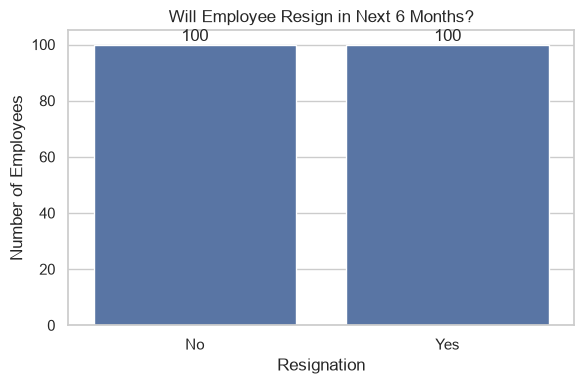

In [35]:
# ============================================================
# 9. TARGET VARIABLE DISTRIBUTION
# ============================================================

target_count = df[target].value_counts()

target_percentage = (
    df[target].value_counts(normalize=True) * 100
).round(2)

target_summary = pd.DataFrame({
    "Count": target_count,
    "Percentage": target_percentage
})

print("\n" + "=" * 70)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 70)
print(target_summary)

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target,
    order=["No", "Yes"]
)

plt.title("Will Employee Resign in Next 6 Months?")
plt.xlabel("Resignation")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()



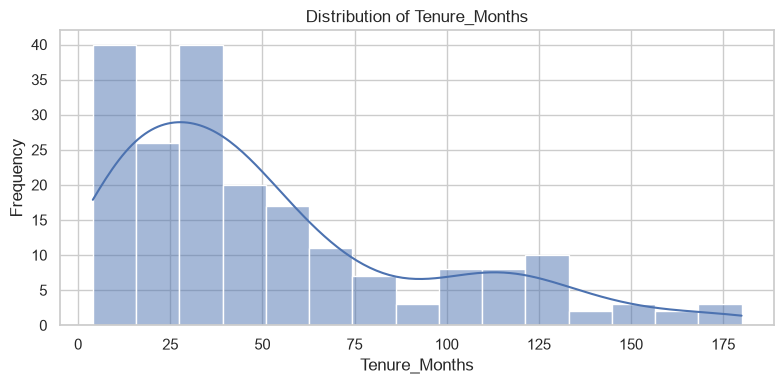

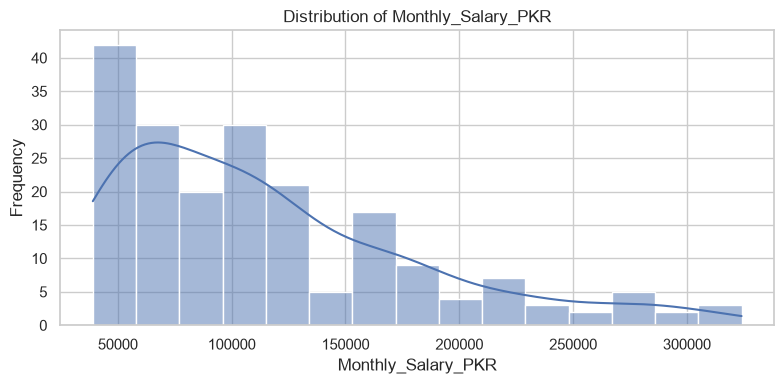

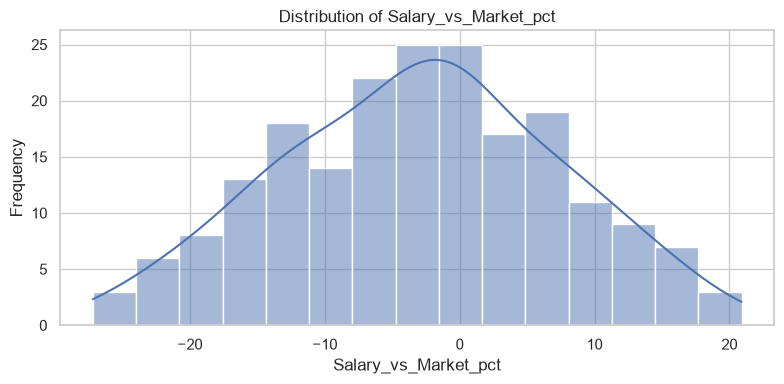

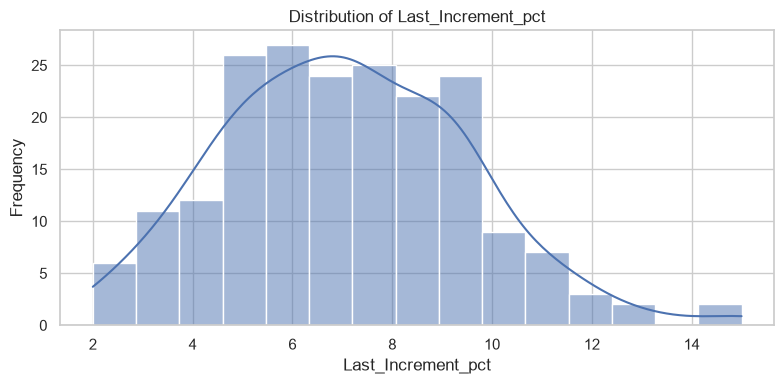

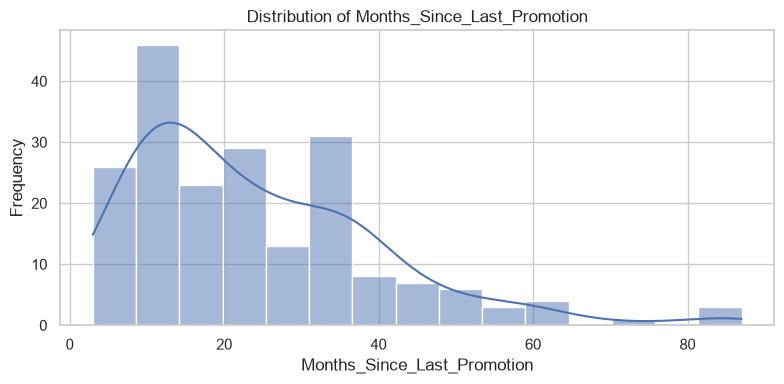

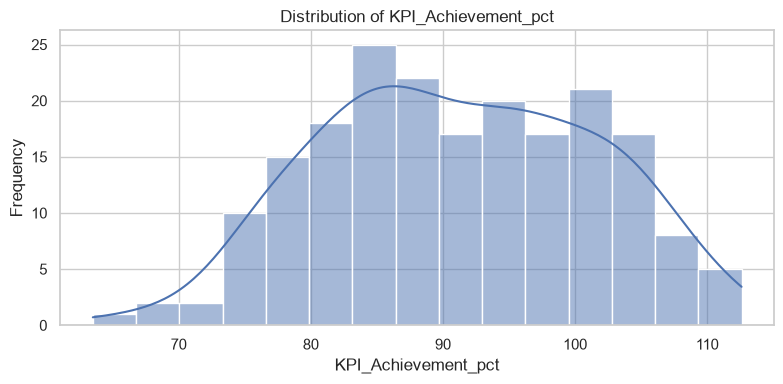

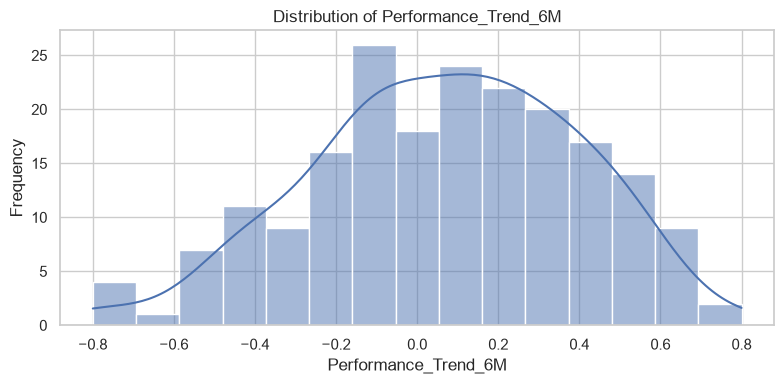

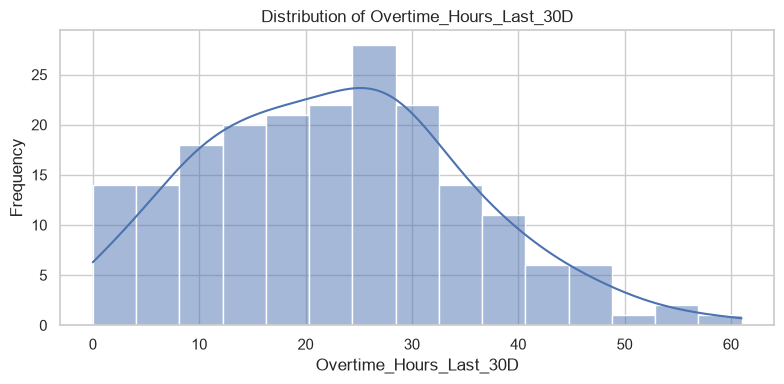

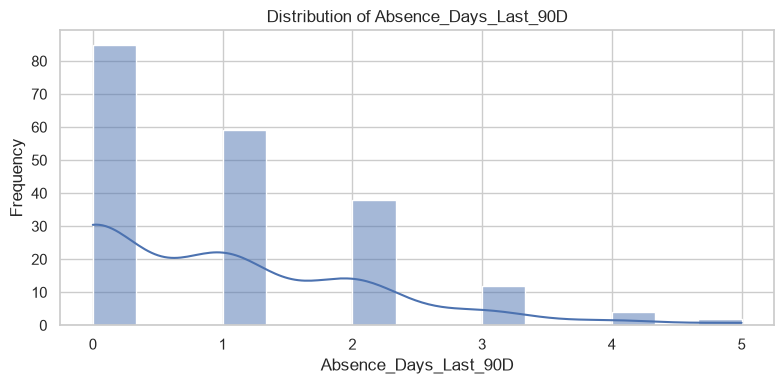

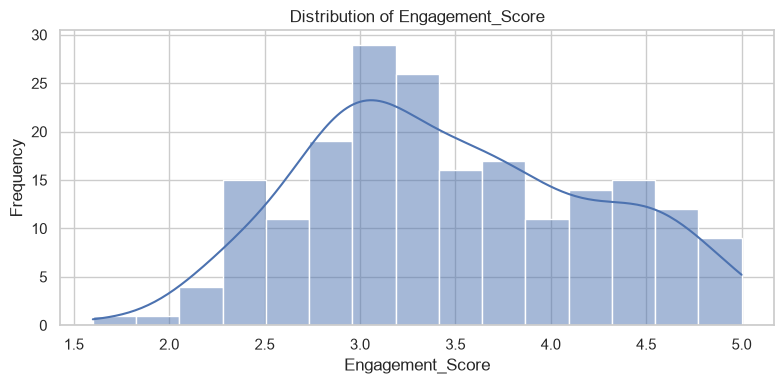

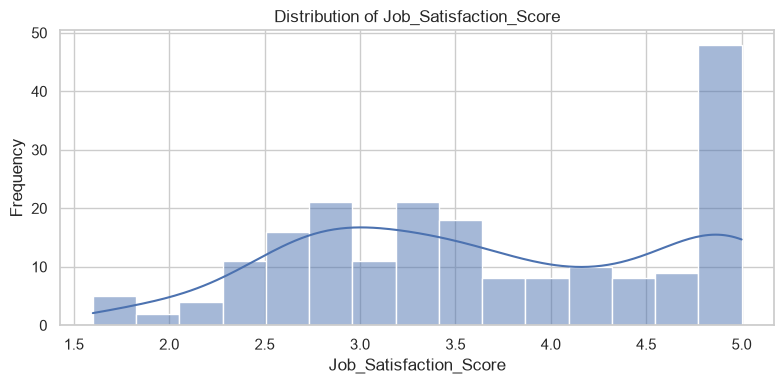

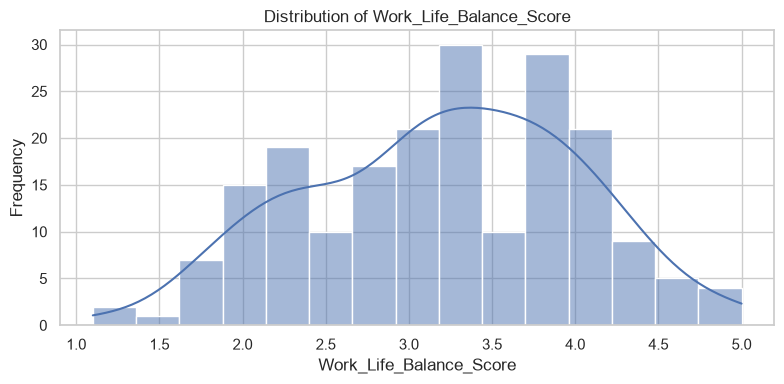

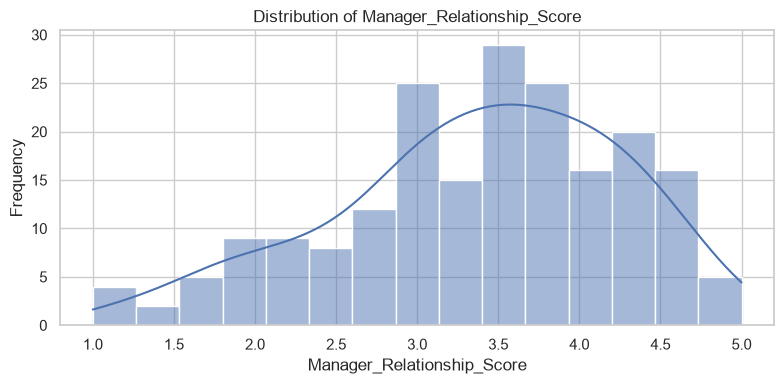

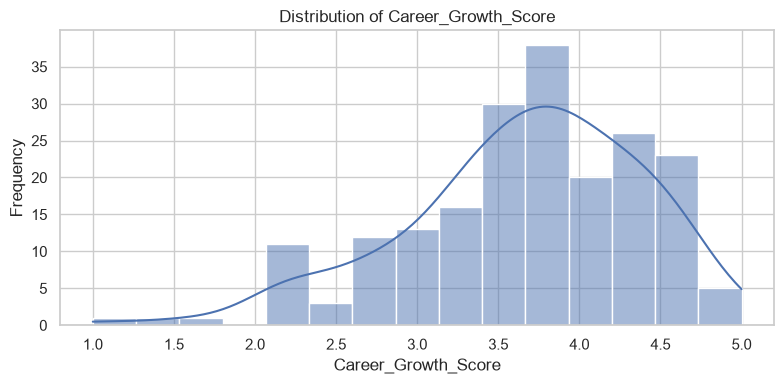

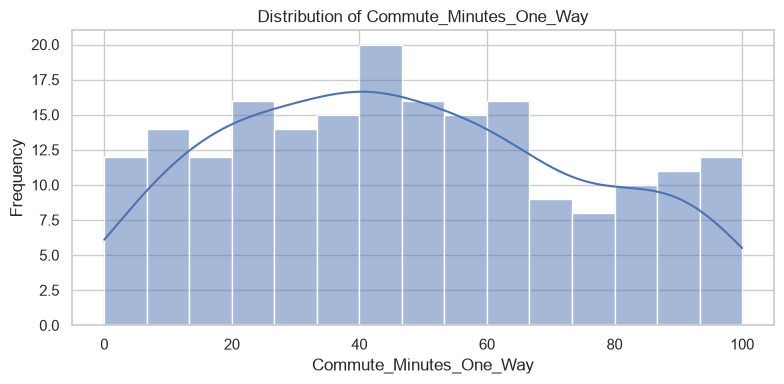

In [36]:
# ============================================================
# 10. NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

for col in numerical_features:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=15
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


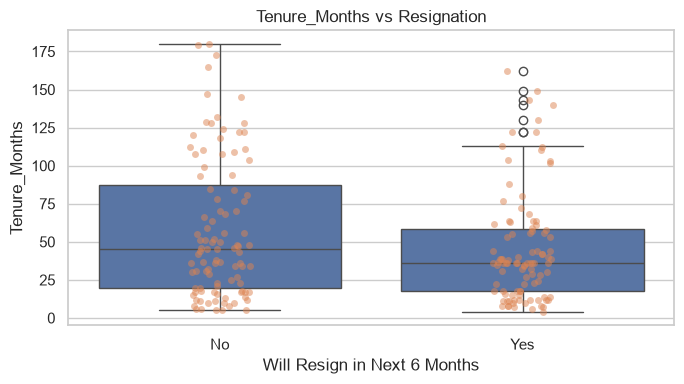

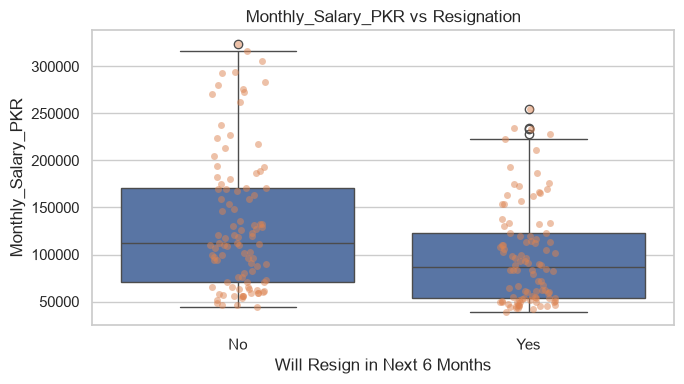

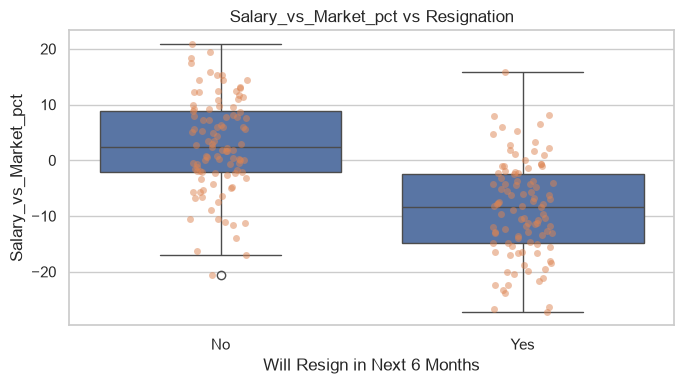

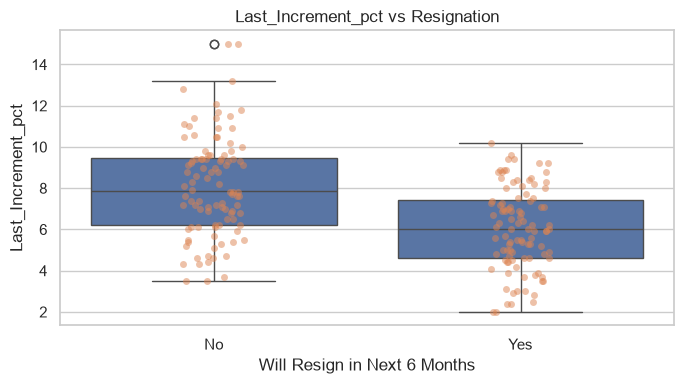

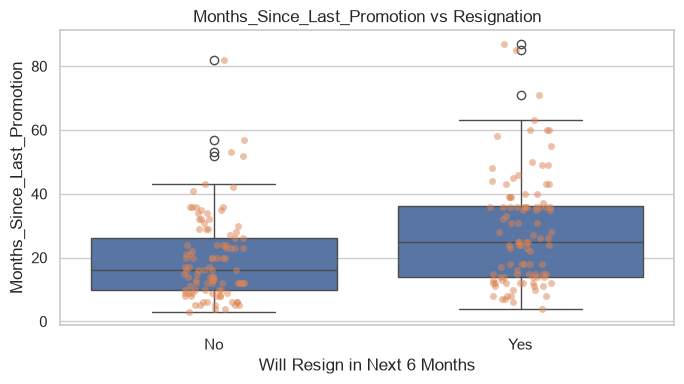

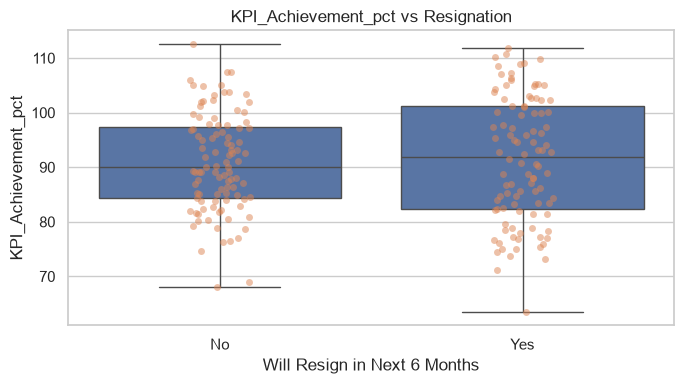

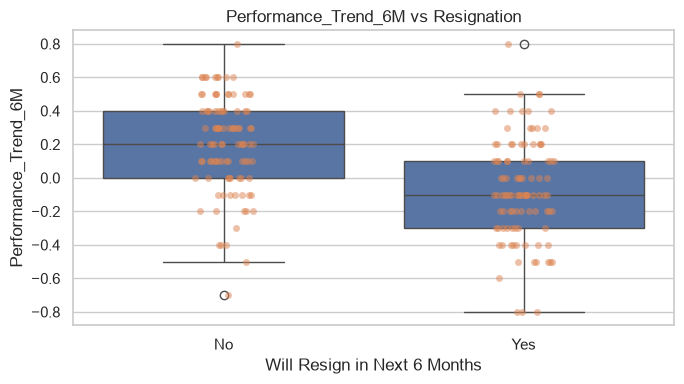

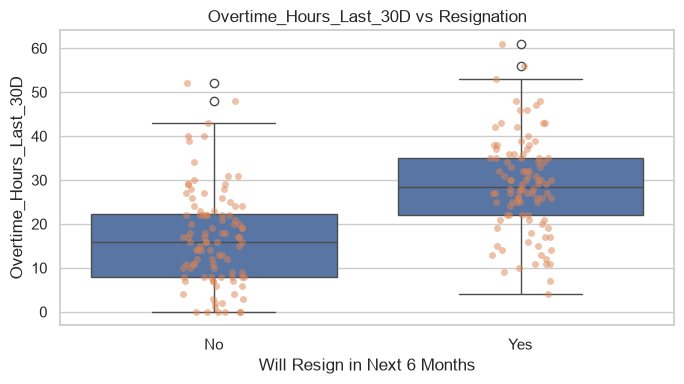

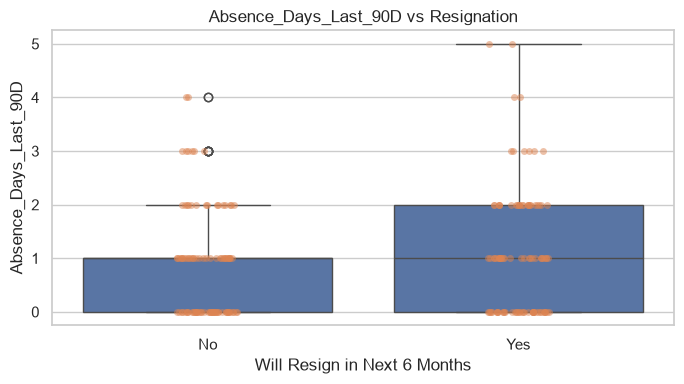

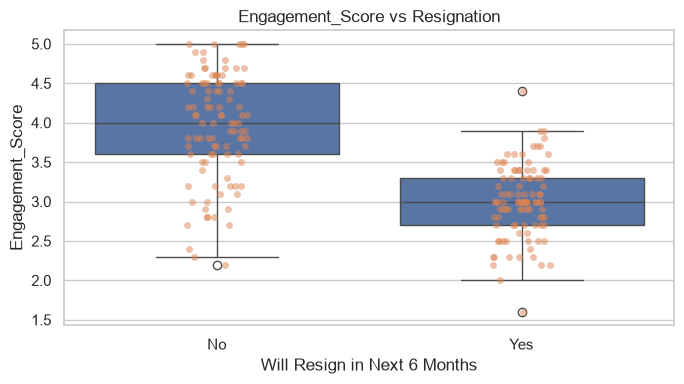

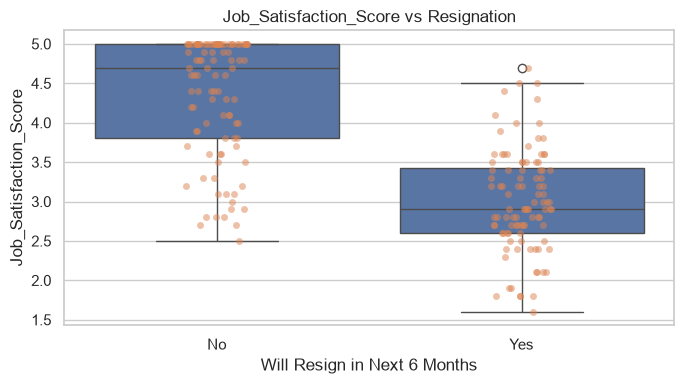

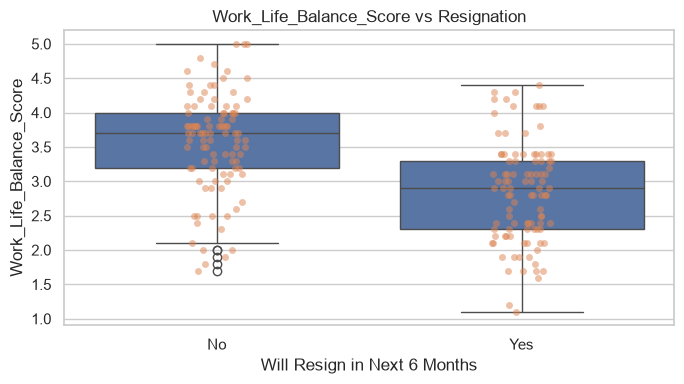

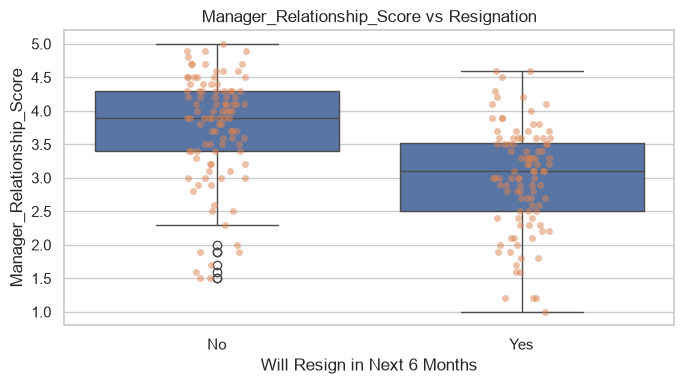

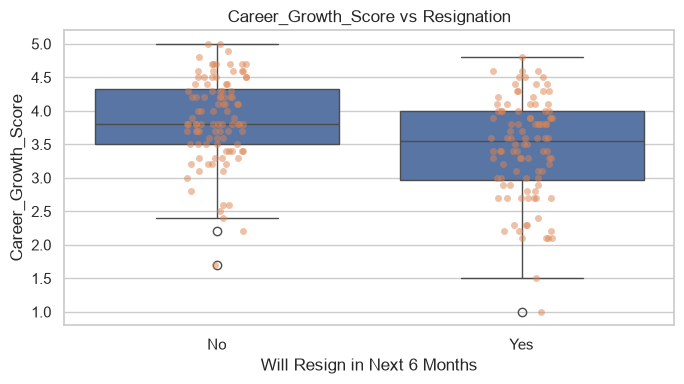

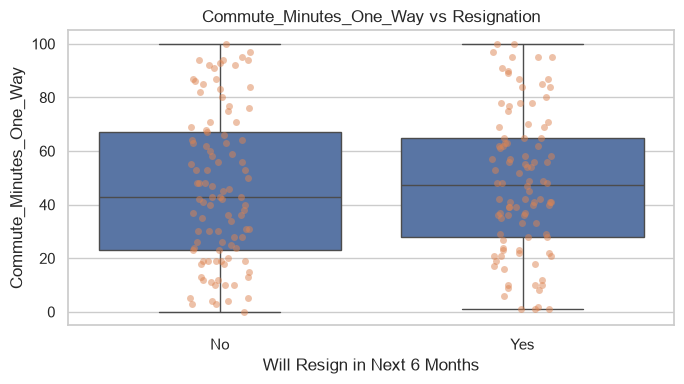

In [14]:
# 11. NUMERICAL FEATURES VS TARGET
# ============================================================

for col in numerical_features:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        order=["No", "Yes"]
    )

    sns.stripplot(
        data=df,
        x=target,
        y=col,
        order=["No", "Yes"],
        alpha=0.5,
        jitter=True
    )

    plt.title(f"{col} vs Resignation")
    plt.xlabel("Will Resign in Next 6 Months")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


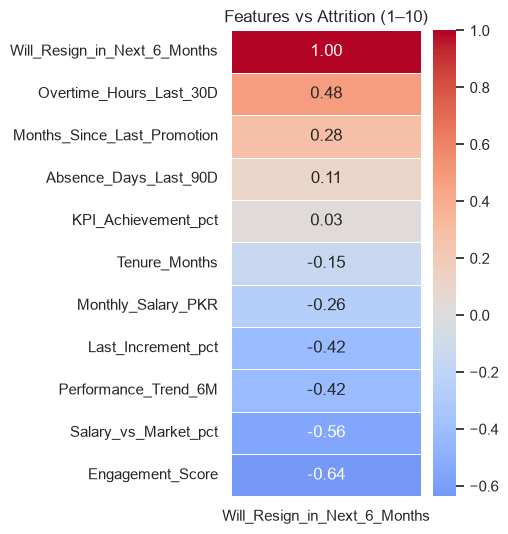

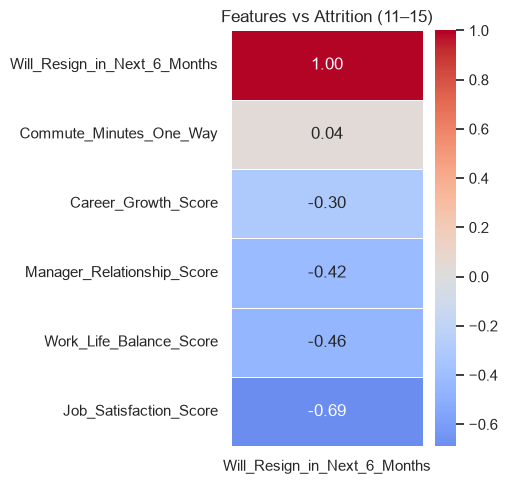

In [15]:
# 19. TARGET CORRELATION WITH 10 FEATURES AT A TIME
# ============================================================

correlation_df = df.copy()

correlation_df[target] = correlation_df[target].map({
    "No": 0,
    "Yes": 1
})

chunk_size = 10

for start in range(
    0,
    len(numerical_features),
    chunk_size
):

    selected_features = numerical_features[
        start:start + chunk_size
    ]

    selected_correlation = (
        correlation_df[
            selected_features + [target]
        ]
        .corr()[[target]]
        .sort_values(
            by=target,
            ascending=False
        )
    )

    plt.figure(
        figsize=(
            5,
            max(5, len(selected_features) * 0.55)
        )
    )

    sns.heatmap(
        selected_correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(
        f"Features vs Attrition "
        f"({start + 1}–"
        f"{start + len(selected_features)})"
    )

    plt.tight_layout()
    plt.show()


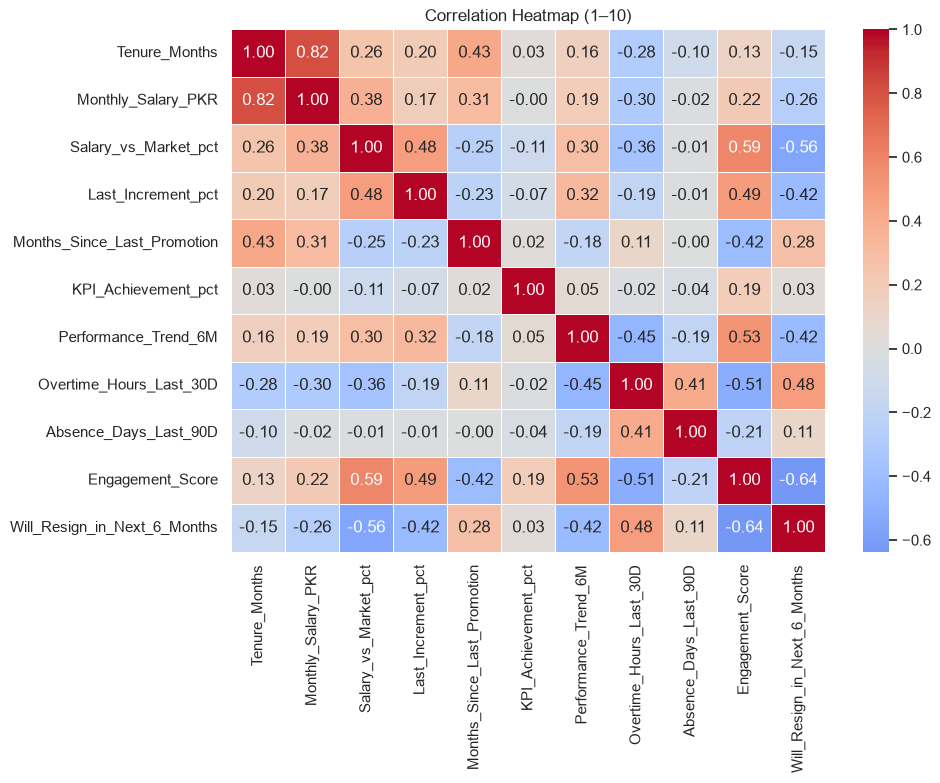

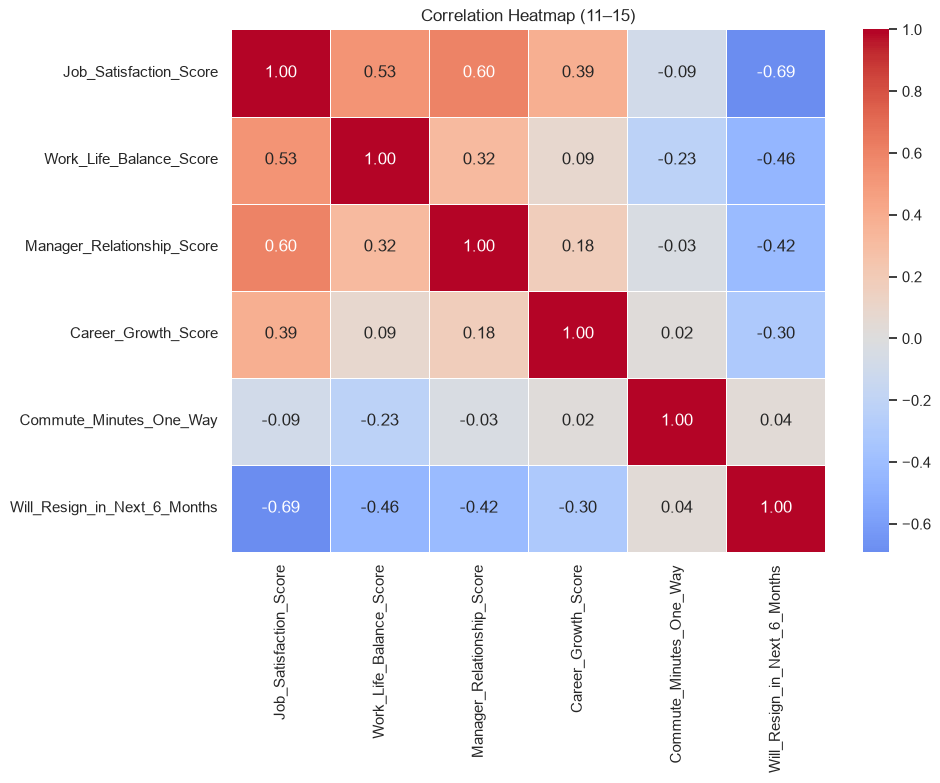

In [16]:
# 20. FULL NUMERICAL CORRELATION HEATMAP IN GROUPS
# ============================================================

for start in range(
    0,
    len(numerical_features),
    chunk_size
):

    selected_features = numerical_features[
        start:start + chunk_size
    ]

    selected_features = selected_features + [target]

    correlation_matrix = (
        correlation_df[selected_features].corr()
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(
        f"Correlation Heatmap "
        f"({start + 1}–"
        f"{start + len(selected_features) - 1})"
    )

    plt.tight_layout()
    plt.show()


In [17]:
# 21. CHECK HIGHLY CORRELATED FEATURES
# ============================================================

correlation_matrix = (
    df[numerical_features]
    .corr()
    .abs()
)

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = []

for column in upper_triangle.columns:

    correlated_features = upper_triangle.index[
        upper_triangle[column] > 0.80
    ].tolist()

    for feature in correlated_features:

        high_correlation_pairs.append({
            "Feature_1": feature,
            "Feature_2": column,
            "Correlation":
                correlation_matrix.loc[
                    feature,
                    column
                ]
        })

high_correlation_df = pd.DataFrame(
    high_correlation_pairs
)

print("\n" + "=" * 70)
print("HIGHLY CORRELATED FEATURE PAIRS")
print("=" * 70)

if high_correlation_df.empty:
    print("No numerical feature pairs above 0.80.")
else:
    print(
        high_correlation_df.sort_values(
            "Correlation",
            ascending=False
        ).round(3)
    )



HIGHLY CORRELATED FEATURE PAIRS
                     Feature_1                Feature_2  Correlation
3  Months_Since_Last_Promotion      Career_Growth_Score        0.885
1             Engagement_Score   Job_Satisfaction_Score        0.863
2      Overtime_Hours_Last_30D  Work_Life_Balance_Score        0.844
0                Tenure_Months       Monthly_Salary_PKR        0.819



MUTUAL INFORMATION RESULTS
                        Feature  Mutual_Information
0                 Employee_Name              0.6931
15       Job_Satisfaction_Score              0.2988
14             Engagement_Score              0.2727
16      Work_Life_Balance_Score              0.1855
7          Salary_vs_Market_pct              0.1737
18          Career_Growth_Score              0.1149
12      Overtime_Hours_Last_30D              0.1137
17   Manager_Relationship_Score              0.1116
11         Performance_Trend_6M              0.1090
8            Last_Increment_pct              0.1073
9   Months_Since_Last_Promotion              0.0869
6            Monthly_Salary_PKR              0.0564
5                 Tenure_Months              0.0363
21   Pay_Concern_Raised_Last_6M              0.0311
1                    Department              0.0132
13        Absence_Days_Last_90D              0.0130
19      Commute_Minutes_One_Way              0.0125
4                    Shift_Type     

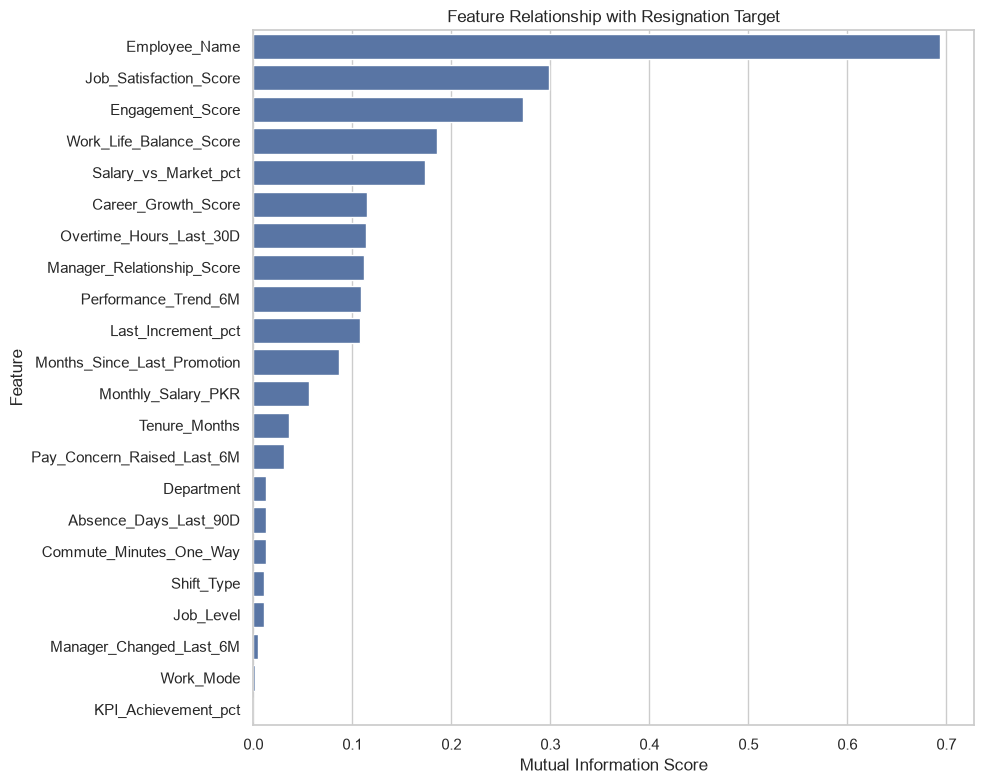


HIGH-PERFORMER AND UNDERPAID EMPLOYEES
    Employee_ID        Department  KPI_Achievement_pct  Salary_vs_Market_pct  \
2        EMP003           Finance                104.9                  -8.9   
3        EMP004           Finance                107.0                 -13.0   
5        EMP006       Engineering                102.4                 -23.3   
8        EMP009  Customer Support                107.3                 -13.4   
16       EMP017  Customer Support                104.4                 -12.8   
18       EMP019                IT                107.5                 -10.5   
27       EMP028             Sales                105.1                 -11.2   
32       EMP033                IT                108.5                 -14.7   
53       EMP054       Engineering                105.9                 -20.1   
59       EMP060             Sales                105.2                 -21.2   
63       EMP064             Sales                110.8                 -22.4   


In [18]:
# 24. MUTUAL INFORMATION FEATURE IMPORTANCE
# ============================================================

model_df = df.drop(
    columns=[id_column]
).copy()

model_df[target] = model_df[target].map({
    "No": 0,
    "Yes": 1
})

categorical_model_features = (
    model_df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

label_encoders = {}

for col in categorical_model_features:

    encoder = LabelEncoder()

    model_df[col] = encoder.fit_transform(
        model_df[col].astype(str)
    )

    label_encoders[col] = encoder

X = model_df.drop(columns=[target])
y = model_df[target]

discrete_features = [
    col in categorical_model_features
    or X[col].nunique() <= 10
    for col in X.columns
]

mutual_information_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

mutual_information_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information":
        mutual_information_scores
})

mutual_information_df = (
    mutual_information_df
    .sort_values(
        by="Mutual_Information",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("MUTUAL INFORMATION RESULTS")
print("=" * 70)
print(mutual_information_df.round(4))

plt.figure(figsize=(10, 8))

sns.barplot(
    data=mutual_information_df,
    x="Mutual_Information",
    y="Feature"
)

plt.title(
    "Feature Relationship with "
    "Resignation Target"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ============================================================
# 25. HIGH-PERFORMER UNDERPAYMENT PATTERN
# ============================================================

df["High_Performer"] = np.where(
    df["KPI_Achievement_pct"] >= 100,
    "Yes",
    "No"
)

df["Underpaid"] = np.where(
    df["Salary_vs_Market_pct"] <= -8,
    "Yes",
    "No"
)

high_performer_underpaid = (
    df[
        (df["High_Performer"] == "Yes")
        & (df["Underpaid"] == "Yes")
    ]
)

print("\n" + "=" * 70)
print("HIGH-PERFORMER AND UNDERPAID EMPLOYEES")
print("=" * 70)

print(
    high_performer_underpaid[
        [
            "Employee_ID",
            "Department",
            "KPI_Achievement_pct",
            "Salary_vs_Market_pct",
            "Last_Increment_pct",
            "Months_Since_Last_Promotion",
            target
        ]
    ]
)



In [20]:
target = "Will_Resign_in_Next_6_Months"


In [21]:
# 4. CONVERT TARGET YES/NO INTO 1/0
# ============================================================

df[target] = df[target].map({
    "No": 0,
    "Yes": 1
})

print("\nTarget values:")
print(df[target].value_counts())




Target values:
Will_Resign_in_Next_6_Months
1    100
0    100
Name: count, dtype: int64


In [24]:
df.head()

,Employee_ID,Employee_Name,Department,Job_Level,Work_Mode,Shift_Type,Tenure_Months,Monthly_Salary_PKR,Salary_vs_Market_pct,Last_Increment_pct,...,Job_Satisfaction_Score,Work_Life_Balance_Score,Manager_Relationship_Score,Career_Growth_Score,Commute_Minutes_One_Way,Manager_Changed_Last_6M,Pay_Concern_Raised_Last_6M,Will_Resign_in_Next_6_Months,High_Performer,Underpaid
0,EMP001,Sonia Hassan,HR,Lead/Manager,Hybrid,Day,140,233000,5.3,5.7,...,4.5,4.4,3.9,2.1,33,No,No,1,Yes,No
1,EMP002,Bilal Aziz,Sales,Mid,Onsite,Rotational,37,132000,19.5,8.8,...,5.0,4.1,4.9,3.5,53,No,No,0,No,No
2,EMP003,Kamran Ali,Finance,Mid,Remote,Day,14,100000,-8.9,5.5,...,4.3,4.7,4.2,4.4,5,No,No,0,Yes,Yes
3,EMP004,Ali Masood,Finance,Mid,Onsite,Day,39,96000,-13.0,2.8,...,2.8,2.9,3.7,3.3,35,No,Yes,1,Yes,Yes
4,EMP005,Farhan Shah,Engineering,Junior,Remote,Day,16,72000,4.8,6.9,...,3.9,4.1,1.8,4.8,1,No,No,1,No,No


In [23]:
# X contains input features
# Employee_ID and Employee_Name are identifiers,
# therefore they should not be used for model training.

X = df.drop(
    columns=[
        "Employee_ID",
        "Employee_Name",
        " KPI_Achievement_pct",
        " Work_Mode ",
        "Commute_Minutes_One_Way",
        "Shift_Type",
        "  Job_Level ",
        "Manager_Changed_Last_6M",
        "Absence_Days_Last_90D",
        " Department ",
        " target"
    ]
)


KeyError: "[' KPI_Achievement_pct', ' Work_Mode ', '  Job_Level ', ' Department ', ' target'] not found in axis"